### Multinomial Logistic Regression (Softmax Regression)
Multinomial Logistic Regression is an extension of binary logistic regression used when the target variable has **more than two discrete classes** (e.g., 3, 4, 10 classes).

Instead of predicting a single probability (as in binary classification), it predicts a **probability distribution across all classes**, ensuring that:

- Each probability lies between 0 and 1
- The sum of probabilities across classes equals 1

#### Core Idea
Binary logistic regression uses the **Sigmoid Function.**  
Multinomial logistic regression uses the **Softmax Function.**

### Mathematical Formulation
##### Step 1: Linear Scores (Logits)
for each class *k*:  
$
z_k = w_k^T x + b_k
$ 

Where:  
- $x$ : feature vector
- $w_k$ : weight vector for class k
- $b_k$ : bias

##### Step 2: Softmax Transformation
$
P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$

This converts raw scores into probabilities.

### Intuition
- Each class gets a *score (logit)*
- Scores compete via exponentiation
- Higher score -> higher probability
- All class probabilities are normalized

### Decision Rule
$
\hat{y} = \arg\max_k P(y = k \mid x)
$

Prediction = class with highest probability

### Cost Function (Loss)
Uses **Categorical Cross-Entropy Loss:**  
$
L = - \sum_{k=1}^{K} y_k \log(P_k)
$

Where:
- $y_k = 1$ for correct class, else 0
- $P_k$ : predicted probability

### Key Differences from Binary Logistic Regression
| Aspect     | Binary Logistic Regression | Multinomial Logistic Regression |
| ---------- | -------------------------- | ------------------------------- |
| Classes    | 2                          | 3 or more                       |
| Activation | Sigmoid                    | Softmax                         |
| Output     | Single probability         | Probability distribution        |
| Loss       | Binary cross-entropy       | Categorical cross-entropy       |


#### Important Concepts
**a. One-vs-Rest vs Multinomial**
- **One-vs-Rest (OvR):** multiple binary classifiers
- **Multinomial:** single model using Softmax

Multinomial captures **class competition better**

**b. Coefficients Interpretation**  
Each class has its own:
- weight vector
- decision boundary

**c. Regularization**  
Supports:
- L1 (Lasso)
- L2 (Ridge)

Helps prevent overfitting

#### Decision Boundary
- Linear boundaries between classes
- In 2D: straight lines separating regions
- In higher dimensions: hyperplanes

#### Advantages
- Simple and interpretable
- Works well for linearly separable multiclass problems
- Probabilistic output

#### Limitations
- Assumes linear separability
- Performance drops for complex nonlinear data
- Sensitive to multicollinearity

### Problem Statement
A telecom company wants to predict the **network issue category** affecting a mobile user session in a 5G network environment.

The prediction system should classify each network session into one of the following categories:

| Class Label | Issue Category             |
| ----------- | -------------------------- |
| 0           | Normal Session             |
| 1           | Congestion Issue           |
| 2           | Signal Weakness            |
| 3           | Packet Loss / Interference |


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, 
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./data/5g_network_dataset.csv")

In [4]:
df.head()

,session_duration_sec,avg_latency_ms,packet_loss_percent,signal_strength_dbm,throughput_mbps,jitter_ms,handover_count,connected_users,cpu_utilization_percent,issue_type
0,479,92,1.94,-69,48,29,4,182,86,1
1,361,36,0.81,-113,90,8,5,82,31,2
2,406,132,5.24,-81,19,31,7,130,84,3
3,408,91,3.20,-73,48,27,7,259,84,1
4,376,102,1.83,-68,45,28,4,207,94,1


In [5]:
df.shape

(50000, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   session_duration_sec     50000 non-null  int64  
 1   avg_latency_ms           50000 non-null  int64  
 2   packet_loss_percent      50000 non-null  float64
 3   signal_strength_dbm      50000 non-null  int64  
 4   throughput_mbps          50000 non-null  int64  
 5   jitter_ms                50000 non-null  int64  
 6   handover_count           50000 non-null  int64  
 7   connected_users          50000 non-null  int64  
 8   cpu_utilization_percent  50000 non-null  int64  
 9   issue_type               50000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 3.8 MB


In [10]:
df.isnull().sum()

session_duration_sec       0
avg_latency_ms             0
packet_loss_percent        0
signal_strength_dbm        0
throughput_mbps            0
jitter_ms                  0
handover_count             0
connected_users            0
cpu_utilization_percent    0
issue_type                 0
dtype: int64

In [11]:
# Feature Selection
X = df.drop("issue_type", axis=1)
y = df["issue_type"]

In [12]:
X.head()

,session_duration_sec,avg_latency_ms,packet_loss_percent,signal_strength_dbm,throughput_mbps,jitter_ms,handover_count,connected_users,cpu_utilization_percent
0,479,92,1.94,-69,48,29,4,182,86
1,361,36,0.81,-113,90,8,5,82,31
2,406,132,5.24,-81,19,31,7,130,84
3,408,91,3.20,-73,48,27,7,259,84
4,376,102,1.83,-68,45,28,4,207,94


In [13]:
y.head()

0    1
1    2
2    3
3    1
4    1
Name: issue_type, dtype: int64

In [14]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (40000, 9)
X_test shape  : (10000, 9)
y_train shape : (40000,)
y_test shape  : (10000,)


In [21]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Model training
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
print(model.classes_)

[0 1 2 3]


In [25]:
print(model.coef_.shape)

(4, 9)


In [27]:
# Prediction
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

print(y_pred[:10])
print(y_prob[:5])

[1 0 3 1 1 1 0 0 0 1]
[[1.13577629e-06 9.99983233e-01 7.26325732e-07 1.49046876e-05]
 [9.99607465e-01 6.86080746e-05 3.23892968e-04 3.38366744e-08]
 [5.69126509e-08 1.73947898e-06 1.03558175e-06 9.99997168e-01]
 [2.94320788e-06 9.99981682e-01 5.38355906e-06 9.99128872e-06]
 [1.91423846e-07 9.99996344e-01 6.69626429e-07 2.79485079e-06]]


In [28]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

In [29]:
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [30]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2503
           1       1.00      1.00      1.00      2481
           2       1.00      1.00      1.00      2533
           3       1.00      1.00      1.00      2483

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2503    0    0    0]
 [   0 2481    0    0]
 [   0    0 2533    0]
 [   0    0    0 2483]]


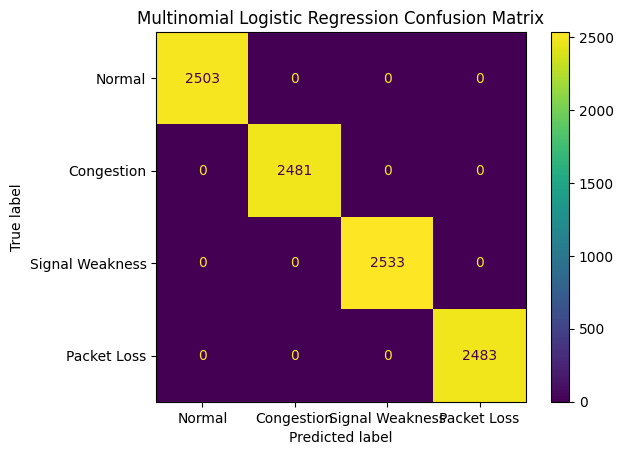

In [32]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Congestion",
        "Signal Weakness",
        "Packet Loss"
    ]
)
disp.plot()

plt.title("Multinomial Logistic Regression Confusion Matrix")

plt.show()

In [34]:
# Model Coefficients
coefficients = pd.DataFrame(
    model.coef_,
    columns=X.columns
)

coefficients.index = [
    "Normal",
    "Congestion",
    "Signal Weakness",
    "Packet Loss"
]

coefficients


,session_duration_sec,avg_latency_ms,packet_loss_percent,signal_strength_dbm,throughput_mbps,jitter_ms,handover_count,connected_users,cpu_utilization_percent
Normal,0.006443,-0.808349,-0.581380,2.239739,2.059918,-0.494375,-1.064608,-0.738854,-0.805920
Congestion,0.323798,-0.263447,-1.805848,2.020821,-0.360755,-0.992495,0.300053,3.112510,1.787909
Signal Weakness,-0.322705,-0.676512,-0.479304,-3.153674,-1.035049,-0.931796,0.179658,-0.740368,-0.785921
Packet Loss,-0.007536,1.748309,2.866532,-1.106886,-0.664114,2.418667,0.584897,-1.633287,-0.196068


In [36]:
# Intercepts
intercepts = pd.DataFrame({
    "Class": [
        "Normal",
        "Congestion",
        "Signal Weakness",
        "Packet Loss"
    ],
    "Intercept": model.intercept_
})

intercepts


,Class,Intercept
0,Normal,-0.480400
1,Congestion,0.521000
2,Signal Weakness,0.566121
3,Packet Loss,-0.606721


In [38]:
# Single Prediction Example
sample_input = pd.DataFrame([{
    "session_duration_sec": 420,
    "avg_latency_ms": 115,
    "packet_loss_percent": 2.3,
    "signal_strength_dbm": -72,
    "throughput_mbps": 38,
    "jitter_ms": 20,
    "handover_count": 6,
    "connected_users": 240,
    "cpu_utilization_percent": 90
}])


# Scale Input
sample_scaled = scaler.transform(sample_input)


# Predict class
prediction = model.predict(sample_scaled)


# Predict probabilites
probabilities = model.predict_proba(sample_scaled)

# Class map Label
class_map = {
    0: "Normal Session",
    1: "Congestion Issue",
    2: "Signal Weakness",
    3: "Packet Loss / Interference"
}

print("Predicted Class :", prediction[0])

print("Predicted Label :", class_map[prediction[0]])

print("\nProbabilities :\n")

for idx, prob in enumerate(probabilities[0]):
    print(f"{class_map[idx]} : {prob:.4f}")


Predicted Class : 1
Predicted Label : Congestion Issue

Probabilities :

Normal Session : 0.0000
Congestion Issue : 1.0000
Signal Weakness : 0.0000
Packet Loss / Interference : 0.0000


In [39]:
# Save Model and Scaler
import joblib
import os

# Folder Name
folder_path = "project-multinomial_logistic_regression"

# Create folder if not exists
os.makedirs(folder_path, exist_ok=True)

# Save Model
joblib.dump(
    model,
    os.path.join(
        folder_path,
        "multinomial_logistic_regression_model.pkl"
    )
)

# Save Scaler
joblib.dump(
    scaler,
    os.path.join(
        folder_path,
        "scaler.pkl"
    )
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [41]:
# Feature Important Analysis
importance = np.mean(np.abs(model.coef_), axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                   Feature  Importance
3      signal_strength_dbm    2.130280
7          connected_users    1.556255
2      packet_loss_percent    1.433266
5                jitter_ms    1.209333
4          throughput_mbps    1.029959
8  cpu_utilization_percent    0.893955
1           avg_latency_ms    0.874155
6           handover_count    0.532304
0     session_duration_sec    0.165121


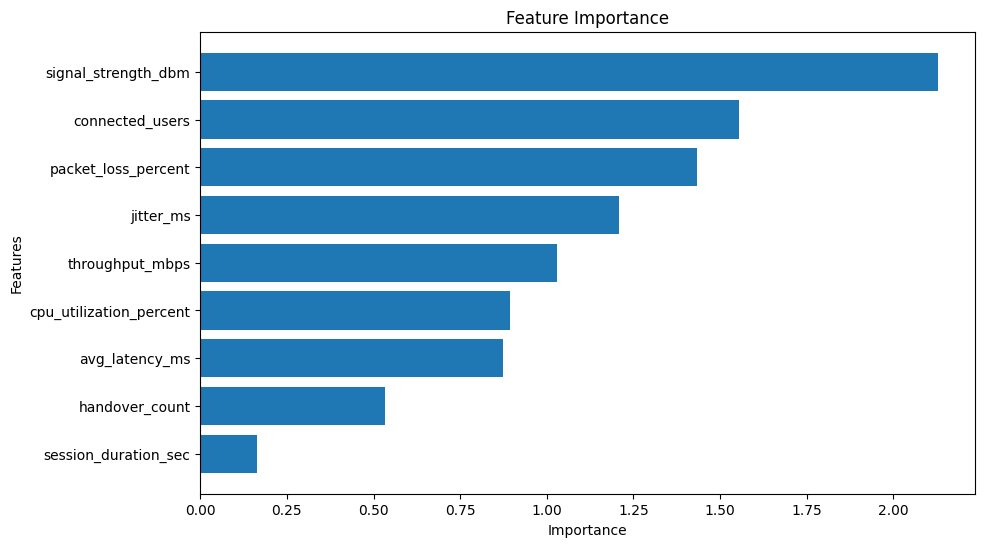

In [42]:
# Feature Importance Visualisation
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()